## Introdução

Criação do ambiente virtual
python -m venv myenv

Ativação do ambiente virtual
myenv/Scripts/activate

Instalação de bibliotcas
pip install pandas matplotlib seaborn ipykernel

### Importação de bibliotecas e leitura dos datasets

In [2]:
# Importando biblioteca
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_portscan = pd.read_csv('./datasets/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv')
df_ddos = pd.read_csv('./datasets/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

In [4]:
df_portscan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286467 entries, 0 to 286466
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             286467 non-null  int64  
 1    Flow Duration                286467 non-null  int64  
 2    Total Fwd Packets            286467 non-null  int64  
 3    Total Backward Packets       286467 non-null  int64  
 4   Total Length of Fwd Packets   286467 non-null  int64  
 5    Total Length of Bwd Packets  286467 non-null  int64  
 6    Fwd Packet Length Max        286467 non-null  int64  
 7    Fwd Packet Length Min        286467 non-null  int64  
 8    Fwd Packet Length Mean       286467 non-null  float64
 9    Fwd Packet Length Std        286467 non-null  float64
 10  Bwd Packet Length Max         286467 non-null  int64  
 11   Bwd Packet Length Min        286467 non-null  int64  
 12   Bwd Packet Length Mean       286467 non-nul

In [4]:
df_ddos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       225745 non-nul

#### Junção dos datasets

In [5]:
df_ddos_portscan = pd.concat([df_ddos, df_portscan], axis=0, ignore_index=True)
df_ddos_portscan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 512212 entries, 0 to 512211
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             512212 non-null  int64  
 1    Flow Duration                512212 non-null  int64  
 2    Total Fwd Packets            512212 non-null  int64  
 3    Total Backward Packets       512212 non-null  int64  
 4   Total Length of Fwd Packets   512212 non-null  int64  
 5    Total Length of Bwd Packets  512212 non-null  int64  
 6    Fwd Packet Length Max        512212 non-null  int64  
 7    Fwd Packet Length Min        512212 non-null  int64  
 8    Fwd Packet Length Mean       512212 non-null  float64
 9    Fwd Packet Length Std        512212 non-null  float64
 10  Bwd Packet Length Max         512212 non-null  int64  
 11   Bwd Packet Length Min        512212 non-null  int64  
 12   Bwd Packet Length Mean       512212 non-nul

In [9]:
df_ddos_portscan.tail()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
512207,443,196135,49,57,1331,105841,570,0,27.163265,108.067176,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
512208,443,378424,49,59,1325,104393,570,0,27.040816,108.095051,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
512209,443,161800,70,103,1427,215903,570,0,20.385714,90.746389,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
512210,443,142864,50,62,1331,110185,570,0,26.620000,107.027727,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
512211,443,186928,46,57,1319,100049,570,0,28.673913,111.438085,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [12]:
label_counts = df_ddos_portscan[' Label'].value_counts()

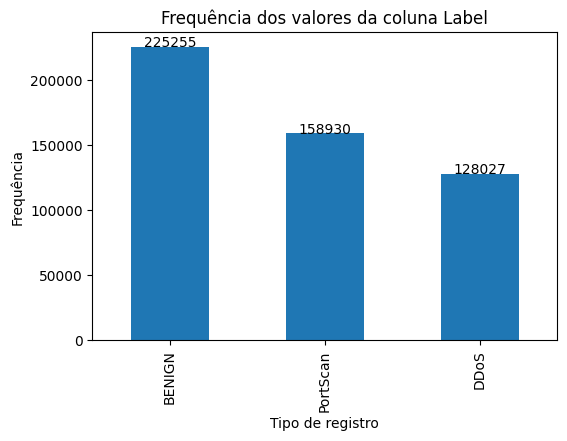

In [23]:


plt.figure(figsize=(6,4))
bars = label_counts.plot(kind='bar')

for i,valor in enumerate(label_counts):
    plt.text(i, valor + 0.1, str(valor), ha='center', fontsize=10)

plt.title('Frequência dos valores da coluna Label')
plt.xlabel('Tipo de registro')
plt.ylabel('Frequência')
plt.show()

### Tratamento de valores ausentes

In [7]:
null_values = df_ddos_portscan.isnull().sum()
null_values

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64

Text(0, 0.5, 'Número de valores ausentes')

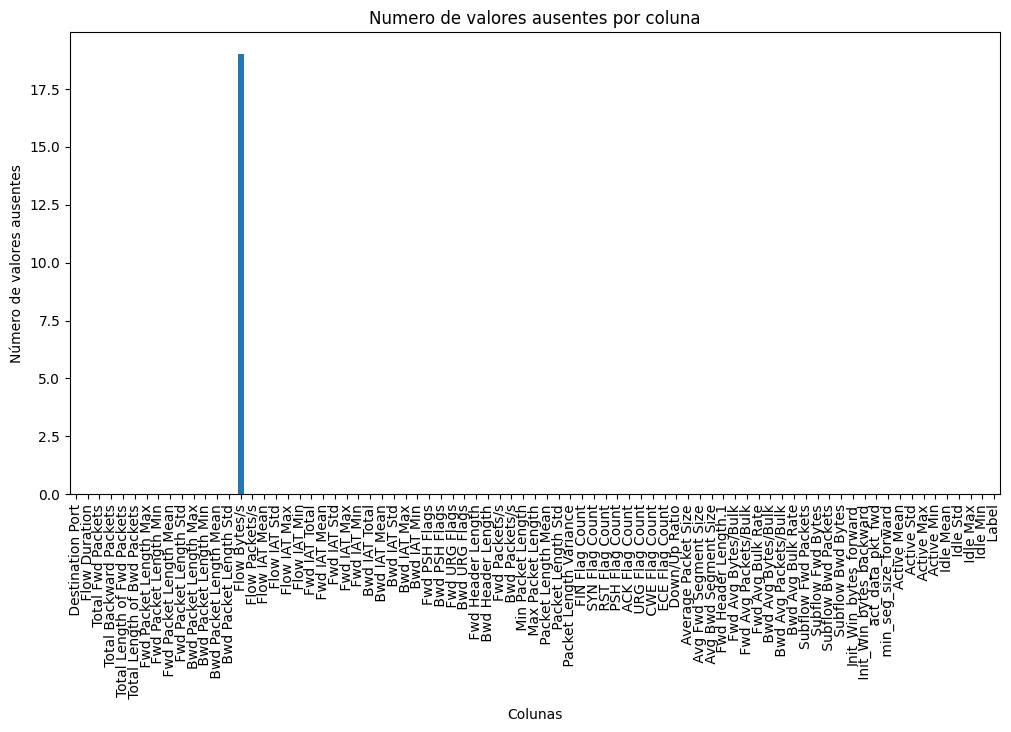

In [9]:
plt.figure(figsize=(12,6))
null_values.plot(kind='bar')
plt.title('Numero de valores ausentes por coluna')
plt.xlabel('Colunas')
plt.ylabel('Número de valores ausentes')

In [18]:
null_values_flow_bytes = null_values['Flow Bytes/s']
null_values_flow_bytes


np.int64(19)

In [19]:
df_ddos_portscan['Flow Bytes/s'].describe()

c:\Users\Felipe\Desktop\ML-DDoS-PortScan\myenv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    5.121930e+05
mean              inf
std               NaN
min     -1.930000e+08
25%      1.568228e+02
50%      2.634817e+04
75%      1.666667e+05
max               inf
Name: Flow Bytes/s, dtype: float64

### Tratamento de valores inf

In [20]:
import numpy as np

In [22]:
df_ddos_portscan_numeric = df_ddos_portscan.iloc[:, :-1].apply(pd.to_numeric, errors='coerce')
df_ddos_portscan_numeric.head()


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0


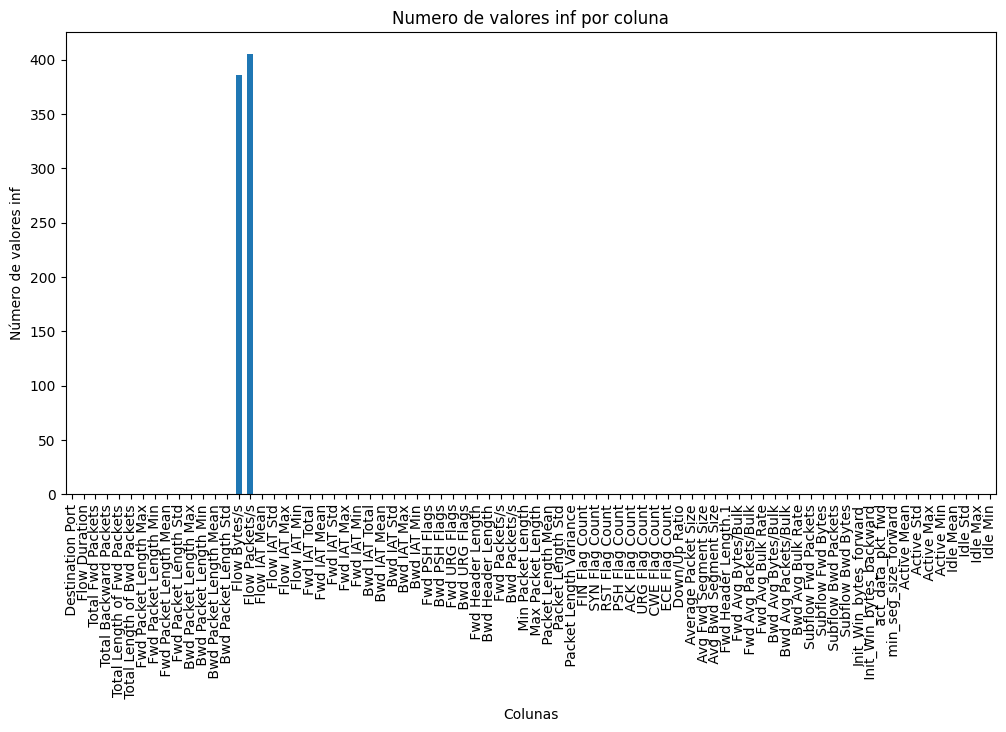

In [23]:
inf_counts = np.isinf(df_ddos_portscan_numeric).sum()
plt.figure(figsize=(12,6))
inf_counts.plot(kind='bar')
plt.title('Numero de valores inf por coluna')
plt.xlabel('Colunas')
plt.ylabel('Número de valores inf')
plt.show()

In [26]:
print(inf_counts['Flow Bytes/s'])
print(inf_counts[' Flow Packets/s'])

386
405


#### Substituindo os valores inf da coluna Flow Bytes/s pela média

In [39]:
# Calculando a média da coluna Flow Bytes/s sem os valores inf
finite_flow_bytes = df_ddos_portscan['Flow Bytes/s'][np.isfinite(df_ddos_portscan['Flow Bytes/s'])]
print('Descrição da coluna Flow Bytes/s sem valores inf')
print(finite_flow_bytes.describe())
print('\nMédia: ')
print(np.mean(finite_flow_bytes))

print('\nMaior valor: ')
print(finite_flow_bytes.max())

Descrição da coluna Flow Bytes/s sem valores inf
count    5.121930e+05
mean     8.828888e+05
std      2.222971e+07
min     -1.930000e+08
25%      1.568228e+02
50%      2.634817e+04
75%      1.666667e+05
max      2.070000e+09
Name: Flow Bytes/s, dtype: float64

Média: 
882888.7740062943

Maior valor: 
2070000000.0


In [34]:
# Substituir os valores inf pela média calculada
df_ddos_portscan['Flow Bytes/s'] = df_ddos_portscan['Flow Bytes/s'].replace([np.inf, -np.inf], np.mean(finite_flow_bytes))

In [35]:
# Exibir dados tratados
print(df_ddos_portscan['Flow Bytes/s'].describe())

count    5.121930e+05
mean     8.828888e+05
std      2.222971e+07
min     -1.930000e+08
25%      1.568228e+02
50%      2.634817e+04
75%      1.666667e+05
max      2.070000e+09
Name: Flow Bytes/s, dtype: float64


#### Substituindo os valores inf da coluna Flow Packets/s pela média

In [42]:
# Calculando a média da coluna Flow Bytes/s sem os valores inf
finite_flow_packets = df_ddos_portscan[' Flow Packets/s'][np.isfinite(df_ddos_portscan[' Flow Packets/s'])]
mean_finite_flow_packets = np.mean(finite_flow_packets)
print('Descrição da coluna Flow Packets/s sem valores inf')
print(finite_flow_packets.describe())
print('\nMédia: ')
print(mean_finite_flow_packets)
print('\nMaior valor: ')
print(finite_flow_packets.max())

Descrição da coluna Flow Packets/s sem valores inf
count    5.118070e+05
mean     4.114101e+04
std      1.644564e+05
min     -2.000000e+06
25%      3.143248e+00
50%      1.653302e+02
75%      3.636364e+04
max      3.000000e+06
Name:  Flow Packets/s, dtype: float64

Média: 
41141.010531900174

Maior valor: 
3000000.0


In [ ]:
# Substituir os valores inf pela média calculada
df_ddos_portscan[' Flow Packets/s'] = df_ddos_portscan[' Flow Packets/s'].replace([np.inf, -np.inf], mean_finite_flow_packets)

In [45]:
# Exibir dados tratados
print(df_ddos_portscan[' Flow Packets/s'].describe())

count    5.122120e+05
mean     4.114101e+04
std      1.643914e+05
min     -2.000000e+06
25%      3.160119e+00
50%      1.656658e+02
75%      3.636364e+04
max      3.000000e+06
Name:  Flow Packets/s, dtype: float64
